In [8]:
import milliontrees
from milliontrees.datasets.TreeBoxes import TreeBoxesDataset
from milliontrees.datasets.milliontrees_dataset import MillionTreesSubset
import pandas as pd
import random

In [2]:
ds_default = TreeBoxesDataset(download=False)

[MillionTrees] Loaded TreeBoxes v0.13 (full)
[MillionTrees] Data dir: data/TreeBoxes_supervised_v0.13
[MillionTrees] Split: random | Images train/test/total: 7305/2540/9845
[MillionTrees] Annotations: 639416 | Sources selected/available: 8/8
[MillionTrees] exclude_sources: ['*unsupervised*']


In [4]:
# ds_boxes = TreeBoxesDataset(
#     download=False,
#     include_sources=["NEON*", "Urban*"],
#     exclude_sources=["*unsupervised*", "NEON_TestSite*"]
# )

# ds_boxes

In [3]:
df = pd.read_csv('data/TreeBoxes_supervised_v0.13/crossgeometry.csv', low_memory=False)

In [4]:
df['source'].unique()

array(['Radogoshi et al. 2021', 'Sun et al. 2022', 'NEON_benchmark',
       'Weecology_University_Florida', 'Reiersen et al. 2022',
       'Dumortier et al. 2025', 'OAM-TCD', 'SelvaBox'], dtype=object)

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from milliontrees import get_dataset
from milliontrees.common.data_loaders import get_eval_loader

ROOT_DIR = "data/"  # <-- change this
N_EXAMPLES = 6

dataset = get_dataset("TreeBoxes", root_dir=ROOT_DIR, download=False)
subset = dataset.get_subset("train")
loader = get_eval_loader("standard", subset, batch_size=N_EXAMPLES)

[MillionTrees] Loaded TreeBoxes v0.13 (full)
[MillionTrees] Data dir: data/TreeBoxes_supervised_v0.13
[MillionTrees] Split: random | Images train/test/total: 7305/2540/9845
[MillionTrees] Annotations: 639416 | Sources selected/available: 8/8
[MillionTrees] exclude_sources: ['*unsupervised*']


16


/var/folders/hl/xnsysyy92l344jvxt2bxy2f00000gn/T/ipykernel_86355/570625124.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  images = np.array(images)


tensor([[4704,    3],
        [4769,    3],
        [4675,    3],
        [4719,    3],
        [4757,    3],
        [4701,    3]])


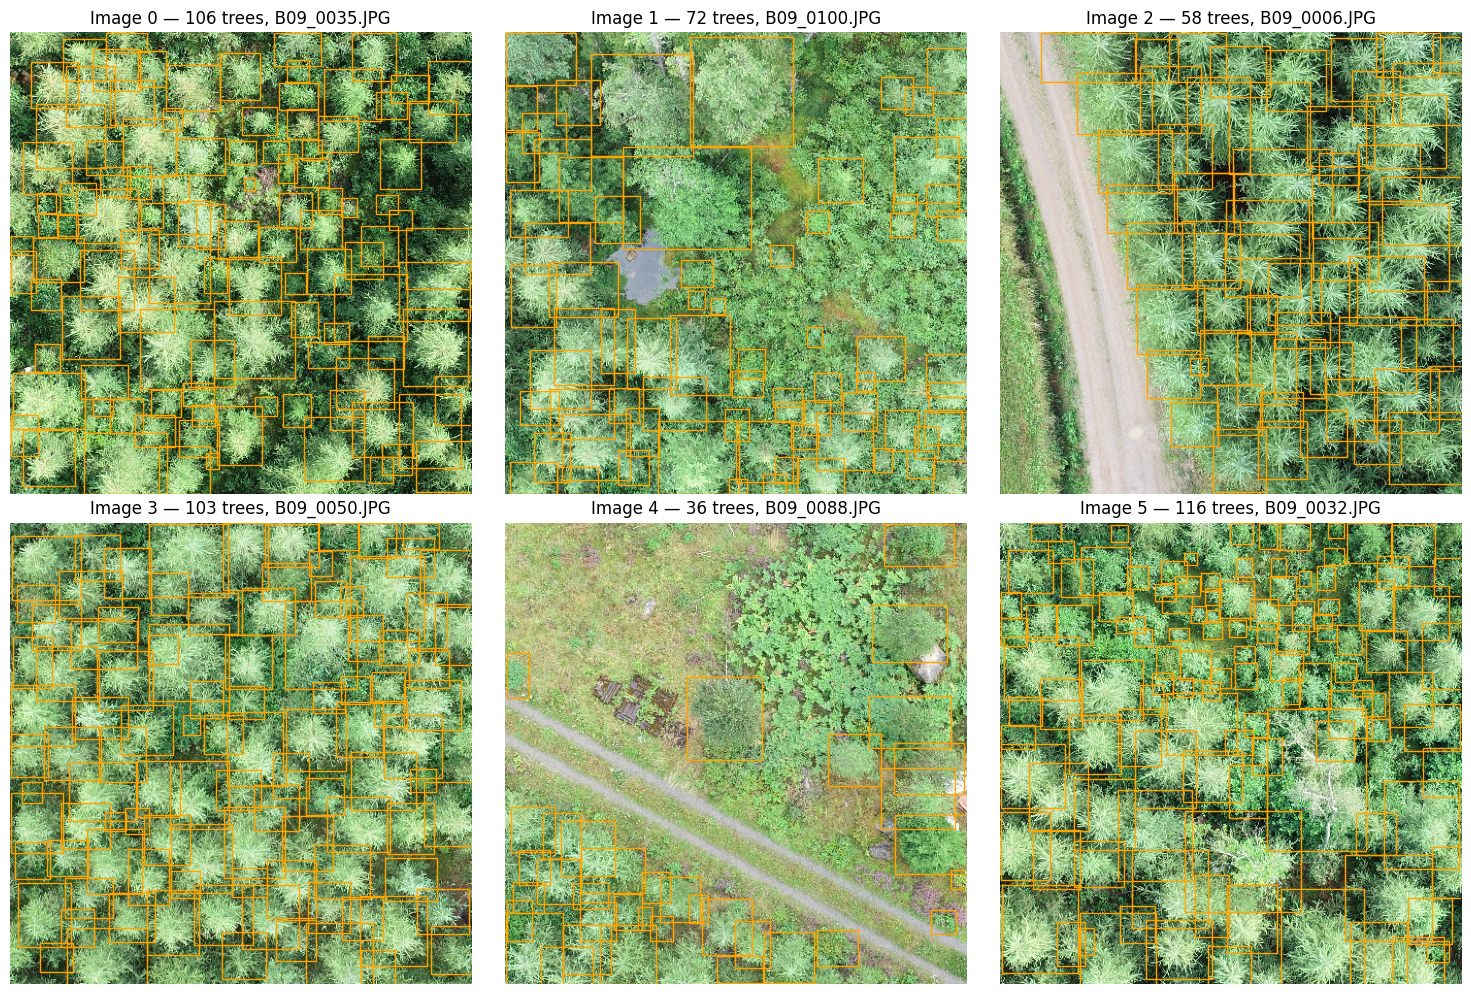

In [10]:

it = iter(loader)
r = int(random.random() * 100)
print(r)
for i in range(r):
    metadata, images, targets = next(it)

images = np.array(images)

print(metadata)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(N_EXAMPLES):
    img = (images[i].transpose(1, 2, 0) * 255).clip(0, 255).astype("uint8")
    boxes = targets[i]["y"].numpy()  # shape (N, 4)

    ax = axes[i]
    ax.imshow(img)
    for box in boxes:
        xmin, ymin, xmax, ymax = box
        rect = patches.Rectangle(
            (xmin, ymin), xmax - xmin, ymax - ymin,
            linewidth=1, edgecolor="orange", facecolor="none"
        )
        ax.add_patch(rect)
    ax.set_title(f"Image {i} — {len(boxes)} trees, {dataset._filename_id_to_code[int(metadata[i][0])]}")
    ax.axis("off")

plt.tight_layout()
plt.savefig("treebox_samples.png", dpi=150)
plt.show()